In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import legendre

import gll1D as gll 
import operadores as op 

N = 8
K = 10
Np = N + 1
a_vel = 2 * np.pi  
FinalTime = 10

vmapM, vmapP = gll.vmap(Np,K)
x, Fscale, rx, nx = gll.fator_geometrico(K,Np)
Dr, V = op.matriz_diferenciaçao(Np)
LIFT = op.Lift(Np,V)

def advecrhs1D(u, time, a):
    alpha = 0.0
    
    u_flat = u.flatten(order='F')
    
    uM = u_flat[vmapM]
    uP = u_flat[vmapP]
    
    #uP[0, 0] = -np.sin(a * time)
    
    du = (uM - uP) * (a * nx - (1.0 - alpha) * np.abs(a * nx)) / 2.0
    
    flux_term = Fscale * du
    surface_term = LIFT @ flux_term
    
    volume_term = -a * rx * (Dr @ u)
    
    return volume_term + surface_term

def advec1D(u, FinalTime, a):
    pp = []
    time = 0.0
    xmin = np.min(np.abs(x[0, :] - x[1, :]))
    
    CFL = 0.5
    dt = CFL / a * xmin
    Nsteps = int(np.ceil(FinalTime / dt))
    dt = FinalTime / Nsteps
    
    resu = np.zeros_like(u)
    
    rk4a = [0.0, -567301805773.0/1357537059087.0, -2404267990393.0/2016746695238.0, -3550918686646.0/2091501179385.0, -1275806237668.0/842570457699.0]
    rk4b = [1432997174477.0/9575080441755.0, 5161836677717.0/13612068292357.0, 1720146321549.0/2090206949498.0, 3134564353537.0/4481467310338.0, 2277821191437.0/14882151754819.0]
    rk4c = [0.0, 1432997174477.0/9575080441755.0, 2526269341429.0/6820363962896.0, 2006345519317.0/3224310063776.0, 2802321613138.0/2924317926251.0]

    for _ in range(Nsteps):
        for intrk in range(5):
            timelocal = time + rk4c[intrk] * dt
            rhsu = advecrhs1D(u, timelocal, a)
            resu = rk4a[intrk] * resu + dt * rhsu
            u = u + rk4b[intrk] * resu
            pp.append(u.flatten(order='F'))
        time += dt
        
    return u, pp

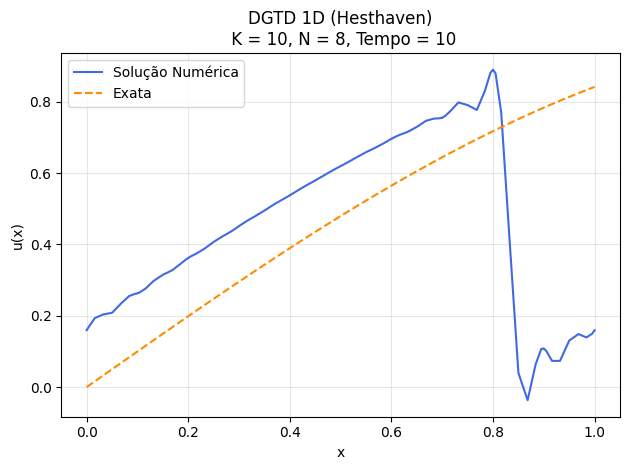

In [4]:
u_initial = np.sin(x)

u_final, pp = advec1D(u_initial, FinalTime, a_vel)

plt.figure()
plt.title(f'DGTD 1D (Hesthaven)\n K = {K}, N = {N}, Tempo = {FinalTime}', fontsize=12)
plt.plot(x.flatten(order='F'), u_final.flatten(order='F'), label='Solução Numérica', color='royalblue')
plt.plot(x.flatten(order='F'), np.sin(x.flatten(order='F') - a_vel * FinalTime), '--', label='Exata', color='darkorange')
plt.ylabel('u(x)')
plt.xlabel('x')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
